# Предсказание сердечных заболеваний

## Описание проекта

**О проекте.** Цель проекта — разработать демонстрационный, а в перспективе и полностью готовый к использованию модуль, который на основе клинических и демографических данных предсказывает вероятность сердечных заболеваний.

**Данный ноутбук** охватывает этапы анализа данных и построения модели. Используемый датасет: [Heart Failure Prediction](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data).

**План этого этапа:**

- Изучение данных — анализ распределений, поиск пропусков и взаимосвязей между признаками;
- Подготовка данных — приведение их к виду, пригодному для обучения;
- Обучение модели — сравнение классических алгоритмов машинного обучения и эксперименты с нейронной сетью;
- Оценка качества — проверка точности предсказаний и надежности модели.

**Результат:** сохраненная обученная модель для последующей интеграции в итоговый функциональный модуль.

## Описание данных

- `Age`: возраст пациента [в годах]

- `Sex`: пол пациента [M: мужской, F: женский]

- `ChestPainType`: тип боли в грудной клетке  
  [TA: типичная стенокардия,  
  ATA: атипичная стенокардия,  
  NAP: боль несердечного происхождения,  
  ASY: бессимптомное течение]

- `RestingBP`: артериальное давление в состоянии покоя [мм рт. ст.]

- `Cholesterol`: уровень холестерина в крови [мг/дл]

- `FastingBS`: уровень глюкозы натощак  
  [1: > 120 мг/дл (повышенный), 0: нормальный]

- `RestingECG`: результаты ЭКГ в состоянии покоя  
  [Normal: норма,  
  ST: отклонения сегмента ST-T (ишемические изменения),  
  LVH: гипертрофия левого желудочка]

- `MaxHR`: максимальная частота сердечных сокращений [60–202]

- `ExerciseAngina`: стенокардия при физической нагрузке  
  [Y: да, N: нет]

- `Oldpeak`: депрессия сегмента ST после нагрузки [показатель ишемии]

- `ST_Slope`: наклон сегмента ST при пиковой нагрузке  
  [Up: восходящий (норма),  
  Flat: горизонтальный (подозрение на ишемию),  
  Down: нисходящий (высокий риск)]

- `HeartDisease`: наличие заболеваний сердца (целевая переменная)  
  [1: есть, 0: нет]


**Примечание:** Есть различия в единицах измерения в РФ, так например в уровень холестерина и глюкозы измеряются в миллимолях на литр, а не мг/дл, что нужно будет учесть при разработке приложения.

## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik

In [2]:
RANDOM_STATE = 130601

In [3]:
pd.options.display.float_format = '{:.2f}'.format

## Подготовка функций

## Первичное ознакомление с данными

In [4]:
try:
    df = pd.read_csv('heart.csv')
except:
    print('Попробуйте поменять название файла')

In [5]:
df.sample(5, random_state=RANDOM_STATE)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
251,48,M,ASY,120,260,0,Normal,115,N,2.00,Flat,1
860,60,M,ASY,130,253,0,Normal,144,Y,1.40,Up,1
611,62,M,TA,135,139,0,ST,137,N,0.20,Up,0
62,45,M,ASY,140,224,0,Normal,144,N,0.00,Up,0
529,72,M,ASY,143,211,0,Normal,109,Y,1.40,Flat,1


Данные выглядят, как хорошо подготовленный датасет, изначально не видно каких-то мусорных значений.

In [6]:
df.shape

(918, 12)

У нас есть 918 наблюдений

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


Явных пропусков нет, типы данных корректны

In [8]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


Здесь проявляются неявные пропуски в значениях `Cholesterol`(холестирин) и `RestingBP`(давление в покое). В показателях `Cholesterol` также могут быть выбросы, судя по максимальному значению. По медиане целевого признака, можно увидеть, что классы почти идеально сбалансированы с небольшим преобладанием в данных наблюдений с наличием сердечного заболевания.

In [9]:
for col in df.select_dtypes(include='str'):
    print()
    print(df[col].value_counts())
    print('===' * 50)


Sex
M    725
F    193
Name: count, dtype: int64

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


### Вывод по первичному ознакомлению
- Есть неявные пропуски в столбцах `Cholesterol` и `RestingBP`.
- Возможны выбросы в `Cholesterol`.
- Дисбаланс классов в целевой переменной пренебрежимо слабый.

## Предобработка данных

### Проверка дубликатов

In [10]:
df.duplicated().sum()

np.int64(0)

В данных нет явных дубликатов.

### Проверка типов данных

In [11]:
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

Все типы данных подобраны верно

### Проверка аномалий

In [12]:
df[df['Cholesterol'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.00,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.70,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.50,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.70,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.40,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.50,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.00,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.00,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.00,Flat,1


Такое количество пропусков явно указывает на пропуски в данных. Попробуем узнать, чем заполнить эти пропуски.

<Axes: >

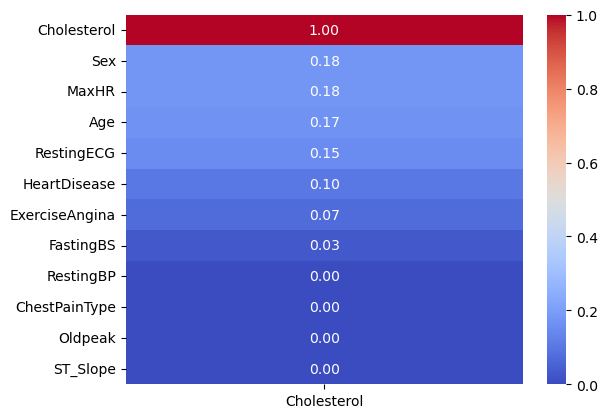

In [13]:
phik_matrix_Cholestrol = df[df['Cholesterol'] != 0].phik_matrix(interval_cols=['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak'])

sns.heatmap(phik_matrix_Cholestrol[['Cholesterol']].sort_values(by='Cholesterol', ascending=False), annot=True, cmap='coolwarm', fmt='.2f')

У холестерина нет сильных корреляций, лучшим решением будет заполнить пропуски медианным значением.

In [14]:
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan).fillna(df['Cholesterol'].median())

<Axes: >

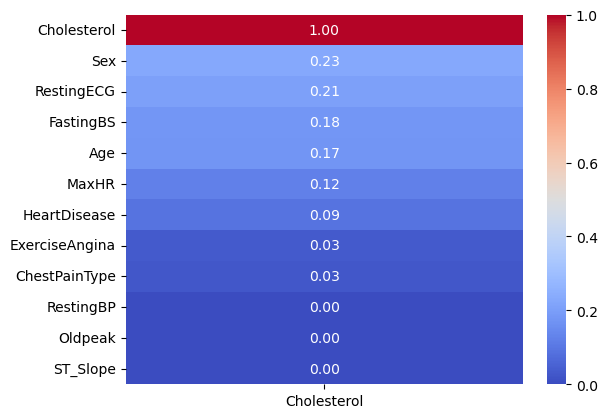

In [15]:
phik_matrix_Cholestrol = df[df['Cholesterol'] != 0].phik_matrix(interval_cols=['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak'])

sns.heatmap(phik_matrix_Cholestrol[['Cholesterol']].sort_values(by='Cholesterol', ascending=False), annot=True, cmap='coolwarm', fmt='.2f')

Видим, что никаких значимых изменений после нашего вмешательство не случилось.

In [16]:
df[df['RestingBP'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,223.00,0,Normal,155,N,1.50,Flat,1


###

###

## Исследовательский анализ данных

## Подготовка данных к обучению

## Обучение моделей

## Выбор лучшей модели

## Результаты